# Análisis de Datos INCI — Exploración, Limpieza y Análisis

**Tres fuentes del mismo conjunto de productos (barcodes):**
- `inci_results_dom_entorno_prueba.jsonl` — DOM scraping: solo los barcodes **que sí se encontraron** en EP/PI (subconjunto válido)
- `inci_results_entorno_prueba.jsonl` — API `/web/products` (entorno de prueba) — datos completos
- `inci_results_pantalla_inicio.jsonl` — API `/web/demo/products` (pantalla inicio) — datos simplificados

> **Relación**: EP y PI barren el mismo rango de barcodes (incluye 404s). DOM solo contiene los barcodes con producto encontrado, por eso DOM ⊆ EP_válidos = PI_válidos.

## 1. Imports y Configuración

In [45]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')

BASE     = Path('.')
PATH_DOM = BASE / 'entorno de prueba' / 'inci_results_dom_entorno_prueba.jsonl'
PATH_EP  = BASE / 'entorno de prueba' / 'inci_results_entorno_prueba.jsonl'
PATH_PI  = BASE / 'pantalla inicio'   / 'inci_results_pantalla_inicio.jsonl'

print('Rutas OK:', all(p.exists() for p in [PATH_DOM, PATH_EP, PATH_PI]))

Rutas OK: True


## 2. Carga de Datos

In [46]:
def load_jsonl(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

raw_dom = load_jsonl(PATH_DOM)
raw_ep  = load_jsonl(PATH_EP)
raw_pi  = load_jsonl(PATH_PI)

# Index por barcode
idx_dom = {r['barcode']: r for r in raw_dom}
idx_ep  = {r['barcode']: r for r in raw_ep}
idx_pi  = {r['barcode']: r for r in raw_pi}

print(f'DOM:              {len(raw_dom):>7,} registros  |  {len(idx_dom):,} barcodes únicos')
print(f'Entorno Prueba:   {len(raw_ep):>7,} registros  |  {len(idx_ep):,} barcodes únicos')
print(f'Pantalla Inicio:  {len(raw_pi):>7,} registros  |  {len(idx_pi):,} barcodes únicos')

DOM:               41,248 registros  |  41,248 barcodes únicos
Entorno Prueba:    64,237 registros  |  64,237 barcodes únicos
Pantalla Inicio:   64,237 registros  |  64,237 barcodes únicos


## 3. Análisis de Estructura JSON

Antes de explorar los datos, mapeamos la estructura real de cada fuente y las **diferencias entre ellas**.

In [47]:
# --- Utilidad: recorrer JSON y mapear árbol de claves con tipos ---
def map_schema(obj, path='', result=None):
    """Recorre recursivamente y devuelve {ruta: tipo} de cada campo hoja."""
    if result is None:
        result = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            full = f'{path}.{k}' if path else k
            if isinstance(v, dict):
                map_schema(v, full, result)
            elif isinstance(v, list):
                result[full] = f'list[{len(v)}]'
                if v and isinstance(v[0], dict):
                    map_schema(v[0], full + '[0]', result)
            else:
                result[full] = type(v).__name__
    return result

# Usar un barcode presente en los 3 con análisis completo
POOL_BARCODES = ['3600550238631', '8431876271584', '8906163410163', '3346131400003', '3596710516902']
SAMPLE_BC = POOL_BARCODES[0]

schema_dom = map_schema(idx_dom[SAMPLE_BC])
schema_ep  = map_schema(idx_ep[SAMPLE_BC])
schema_pi  = map_schema(idx_pi[SAMPLE_BC])

all_paths = sorted(set(schema_dom) | set(schema_ep) | set(schema_pi))

df_schema = pd.DataFrame({
    'ruta': all_paths,
    'DOM':  [schema_dom.get(p, '—') for p in all_paths],
    'EP':   [schema_ep.get(p, '—')  for p in all_paths],
    'PI':   [schema_pi.get(p, '—')  for p in all_paths],
})

# Marcar exclusividad
def exclusivity(row):
    present = [s for s in ['DOM','EP','PI'] if row[s] != '—']
    if len(present) == 3: return 'en los 3'
    if len(present) == 1: return f'solo {present[0]}'
    return f'solo {" y ".join(present)}'

df_schema['exclusividad'] = df_schema.apply(exclusivity, axis=1)

print(f'Campos totales mapeados: {len(df_schema)}')
print(df_schema['exclusividad'].value_counts().to_string())

Campos totales mapeados: 107
exclusividad
solo DOM        54
solo EP y PI    36
solo EP         16
en los 3         1


In [48]:
print('\n=== CAMPOS COMUNES (en los 3 fuentes) ===')
common_fields = df_schema[df_schema['exclusividad'] == 'en los 3']
print(common_fields[['ruta','DOM','EP','PI']].to_string(index=False))


=== CAMPOS COMUNES (en los 3 fuentes) ===
   ruta DOM  EP  PI
barcode str str str


In [49]:
print('\n=== CAMPOS EXCLUSIVOS DE DOM (no están en EP ni PI) ===')
only_dom = df_schema[df_schema['exclusividad'] == 'solo DOM']
print(only_dom[['ruta','DOM']].to_string(index=False))

print('\n=== CAMPOS EXCLUSIVOS DE EP (no están en PI ni DOM) ===')
only_ep = df_schema[df_schema['exclusividad'] == 'solo EP']
print(only_ep[['ruta','EP']].to_string(index=False))


=== CAMPOS EXCLUSIVOS DE DOM (no están en EP ni PI) ===
                                                              ruta      DOM
                                         dom_data.allergenWarnings  list[0]
                                         dom_data.cleanBeautyScore      int
                                   dom_data.compatibilityConflicts  list[0]
                            dom_data.efficacySummary.evidenceScore      int
                 dom_data.efficacySummary.evidencedIngredientCount      int
                               dom_data.efficacySummary.topEffects  list[5]
          dom_data.efficacySummary.topEffects[0].bestEvidenceLevel      str
          dom_data.efficacySummary.topEffects[0].compositeStrength      str
dom_data.efficacySummary.topEffects[0].contributingIngredientCount      int
    dom_data.efficacySummary.topEffects[0].contributingIngredients  list[1]
                     dom_data.efficacySummary.topEffects[0].target      str
                dom_data.enviro

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Sheen\AppData\Local\Temp\ipykernel_23060\1060773671.py:4: SyntaxWarning: invalid escape sequence '\.'
  top_level = top_level[top_level['ruta'].str.count('\.') <= 3].copy()


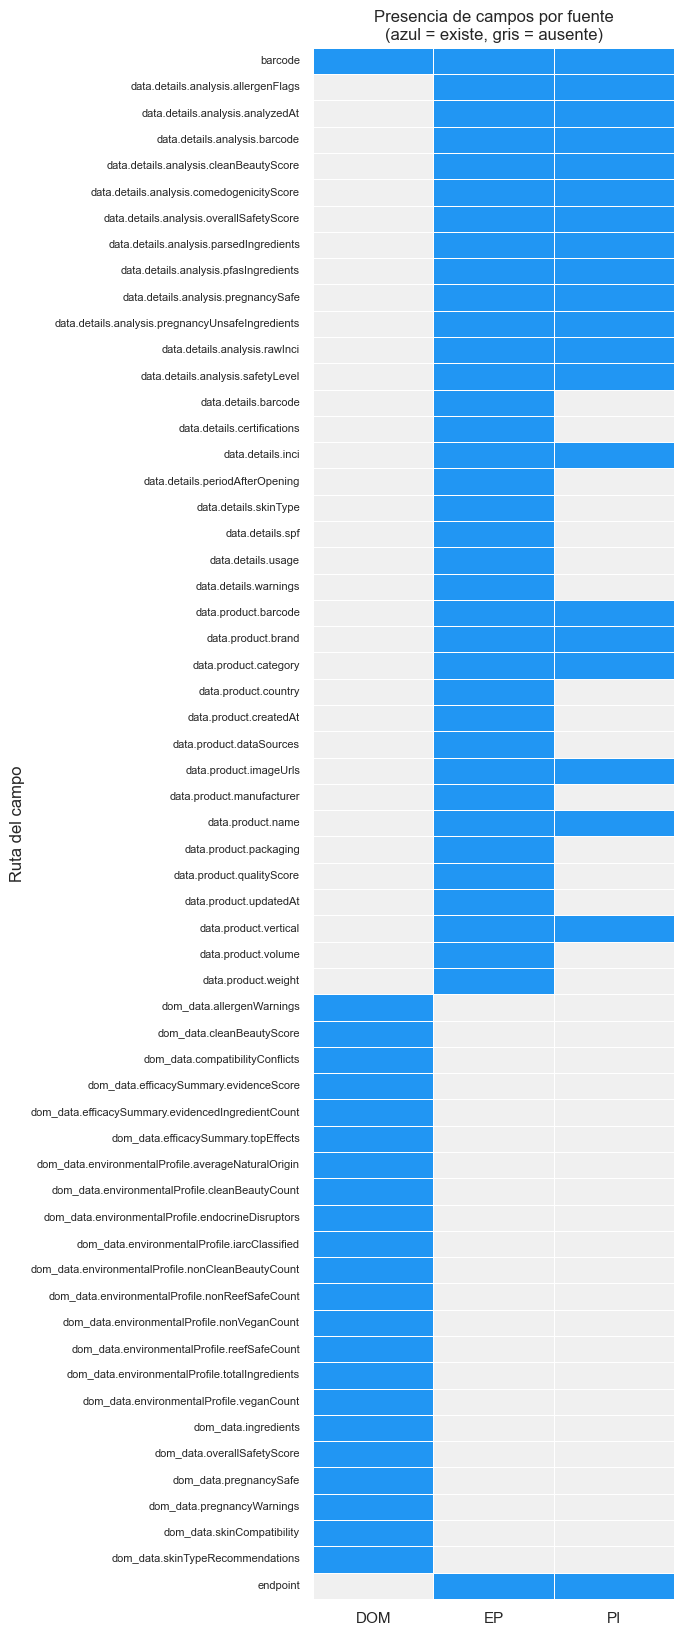

In [50]:
# Visualización: mapa de calor de presencia por fuente
# Seleccionar rutas de nivel 1-2 para legibilidad
top_level = df_schema[~df_schema['ruta'].str.contains(r'\[0\]')].copy()
top_level = top_level[top_level['ruta'].str.count('\.') <= 3].copy()

heatmap_data = top_level.set_index('ruta')[['DOM','EP','PI']].map(
    lambda x: 1 if x != '—' else 0
)

fig, ax = plt.subplots(figsize=(7, max(8, len(heatmap_data) * 0.28)))
sns.heatmap(
    heatmap_data,
    cmap=['#f0f0f0', '#2196F3'],
    linewidths=0.5, linecolor='white',
    cbar=False, ax=ax,
    annot=False
)
ax.set_title('Presencia de campos por fuente\n(azul = existe, gris = ausente)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Ruta del campo')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

In [51]:
# Diferencias estructurales clave documentadas
print('=' * 65)
print('DIFERENCIAS ESTRUCTURALES CLAVE ENTRE FUENTES')
print('=' * 65)

diffs = [
    ('details.inci',
     'EP: list de strings  |  PI: string único concatenado'),
    ('overallSafetyScore',
     'DOM: escala 0-100    |  EP/PI: escala 0-10 (factor x10)'),
    ('ingredients[0].safetyRating vs safetyScore',
     'DOM usa safetyRating |  EP/PI usan safetyScore'),
    ('ingredients[0].allergenType',
     'DOM: campo singular  |  EP/PI: allergenTypes (lista)'),
    ('Producto metadata',
     'EP: +9 campos extra  |  PI: versión reducida del catálogo'),
    ('Secciones únicas DOM',
     'efficacySummary, environmentalProfile, skinTypeRecommendations,\n                      skinCompatibility, compatibilityConflicts'),
    ('Secciones únicas EP',
     'details.spf, certifications, skinType, usage, warnings,\n                      periodAfterOpening, qualityScore, dataSources'),
]
for campo, desc in diffs:
    print(f'  • {campo}:')
    print(f'    {desc}')
print('=' * 65)

DIFERENCIAS ESTRUCTURALES CLAVE ENTRE FUENTES
  • details.inci:
    EP: list de strings  |  PI: string único concatenado
  • overallSafetyScore:
    DOM: escala 0-100    |  EP/PI: escala 0-10 (factor x10)
  • ingredients[0].safetyRating vs safetyScore:
    DOM usa safetyRating |  EP/PI usan safetyScore
  • ingredients[0].allergenType:
    DOM: campo singular  |  EP/PI: allergenTypes (lista)
  • Producto metadata:
    EP: +9 campos extra  |  PI: versión reducida del catálogo
  • Secciones únicas DOM:
    efficacySummary, environmentalProfile, skinTypeRecommendations,
                      skinCompatibility, compatibilityConflicts
  • Secciones únicas EP:
    details.spf, certifications, skinType, usage, warnings,
                      periodAfterOpening, qualityScore, dataSources


## 4. Cobertura de Datos y Relación entre Fuentes

=== Relación entre fuentes ===
EP total barcodes:             64,237
  → 404 / no encontrados:      22,989  (35.8%)
  → Encontrados (válidos):     41,248  (64.2%)
    → Con análisis completo:   17,577  (27.4%)
    → Sin análisis/ingred.:    23,671  (36.8%)

DOM barcodes (=EP válidos):    41,248
  DOM ⊆ EP_válidos:          True
  DOM ⊆ PI_válidos:          False


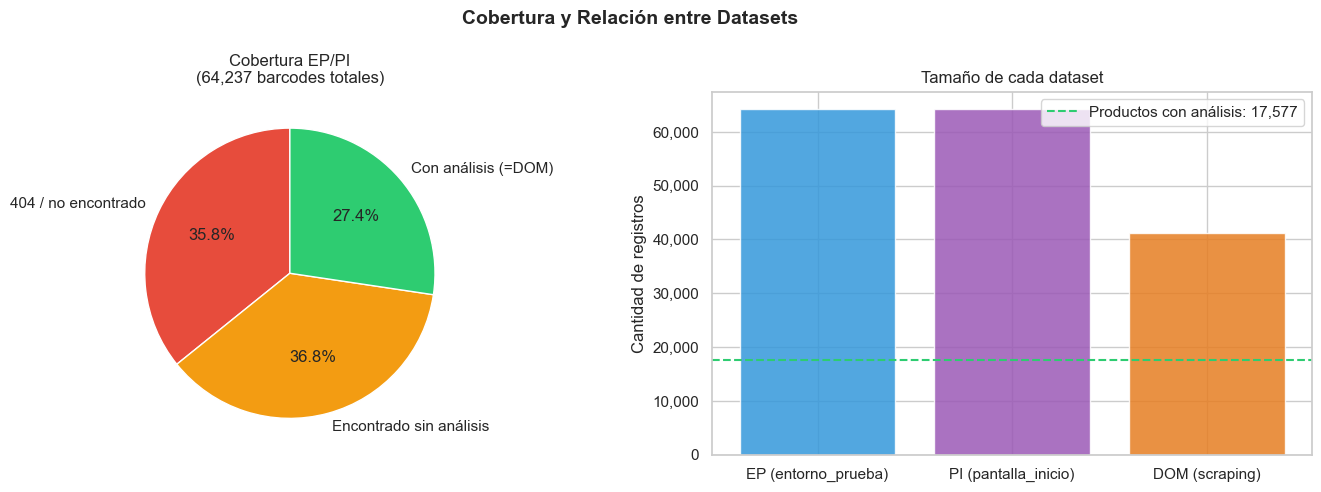

In [52]:
# Clasificar cada barcode en EP
ep_valid    = {r['barcode'] for r in raw_ep if r.get('data', {}).get('product')}
ep_not_found = {r['barcode'] for r in raw_ep if 'statusCode' in r.get('data', {})}
ep_no_ingr  = {r['barcode'] for r in raw_ep
               if r.get('data', {}).get('product')
               and not (r.get('data', {}).get('details') or {}).get('analysis')}
ep_with_anal = {r['barcode'] for r in raw_ep
                if (r.get('data', {}).get('details') or {}).get('analysis')}

dom_barcodes = set(idx_dom.keys())

print('=== Relación entre fuentes ===')
print(f'EP total barcodes:           {len(idx_ep):>8,}')
print(f'  → 404 / no encontrados:    {len(ep_not_found):>8,}  ({100*len(ep_not_found)/len(idx_ep):.1f}%)')
print(f'  → Encontrados (válidos):   {len(ep_valid):>8,}  ({100*len(ep_valid)/len(idx_ep):.1f}%)')
print(f'    → Con análisis completo: {len(ep_with_anal):>8,}  ({100*len(ep_with_anal)/len(idx_ep):.1f}%)')
print(f'    → Sin análisis/ingred.:  {len(ep_no_ingr):>8,}  ({100*len(ep_no_ingr)/len(idx_ep):.1f}%)')
print()
print(f'DOM barcodes (=EP válidos):  {len(dom_barcodes):>8,}')
print(f'  DOM ⊆ EP_válidos:          {dom_barcodes == ep_valid}')
print(f'  DOM ⊆ PI_válidos:          {dom_barcodes <= {r["barcode"] for r in raw_pi if r.get("data",{}).get("product")}}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie EP
ep_pie = {
    '404 / no encontrado': len(ep_not_found),
    'Encontrado sin análisis': len(ep_valid) - len(ep_with_anal),
    'Con análisis (=DOM)': len(ep_with_anal),
}
axes[0].pie(
    ep_pie.values(),
    labels=ep_pie.keys(),
    autopct='%1.1f%%',
    colors=['#e74c3c', '#f39c12', '#2ecc71'],
    startangle=90
)
axes[0].set_title('Cobertura EP/PI\n(64,237 barcodes totales)', fontsize=12)

# Barras apiladas mostrando la relación
data_stack = pd.DataFrame({
    'Fuente': ['EP', 'PI', 'DOM'],
    'Barcodes': [len(raw_ep), len(raw_pi), len(raw_dom)],
    'Con análisis': [len(ep_with_anal), len(ep_with_anal), len(dom_barcodes)],
})
axes[1].bar(['EP (entorno_prueba)', 'PI (pantalla_inicio)', 'DOM (scraping)'],
            [len(raw_ep), len(raw_pi), len(dom_barcodes)],
            color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='white', alpha=0.85)
axes[1].axhline(len(ep_with_anal), color='#2ecc71', linestyle='--', linewidth=1.5,
                label=f'Productos con análisis: {len(ep_with_anal):,}')
axes[1].set_title('Tamaño de cada dataset', fontsize=12)
axes[1].set_ylabel('Cantidad de registros')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Cobertura y Relación entre Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Comparación de Pool — Mismo Barcode en los 3 Datasets

In [53]:
# Pool: 5 barcodes con análisis completo en las 3 fuentes
# (ya verificados en exploración)

def extract_pool_row(barcode, ep_rec, pi_rec, dom_rec):
    ep_prod  = ep_rec['data']['product']
    ep_det   = ep_rec['data']['details']
    ep_anal  = ep_det['analysis']
    pi_prod  = pi_rec['data']['product']
    pi_det   = pi_rec['data']['details']
    pi_anal  = pi_det['analysis']
    dom_data = dom_rec['dom_data']

    # inci: EP es lista, PI es string
    ep_inci_count = len(ep_det.get('inci', []) or [])
    pi_inci_str   = pi_det.get('inci', '') or ''
    pi_inci_count = len([x for x in pi_inci_str.split(',') if x.strip()]) if pi_inci_str else 0

    return {
        'barcode':                barcode,
        'nombre':                 ep_prod.get('name', ''),
        'marca':                  ep_prod.get('brand', ''),
        'país':                   ep_prod.get('country', ''),
        'quality_score_EP':       ep_prod.get('qualityScore'),
        # INCI
        'n_inci_EP_lista':        ep_inci_count,
        'n_inci_PI_string':       pi_inci_count,
        'n_parsed_ingr_EP':       len(ep_anal.get('parsedIngredients', []) or []),
        'n_parsed_ingr_PI':       len(pi_anal.get('parsedIngredients', []) or []),
        'n_ingr_DOM':             len(dom_data.get('ingredients', []) or []),
        # Safety (escalas distintas!)
        'safety_EP_010':          ep_anal.get('overallSafetyScore'),
        'safety_PI_010':          pi_anal.get('overallSafetyScore'),
        'safety_DOM_0100':        dom_data.get('overallSafetyScore'),
        'safety_DOM_norm_010':    round(dom_data.get('overallSafetyScore', 0) / 10, 1),
        'safety_level_EP':        ep_anal.get('safetyLevel'),
        'safety_level_PI':        pi_anal.get('safetyLevel'),
        # Clean beauty
        'clean_beauty_EP':        ep_anal.get('cleanBeautyScore'),
        'clean_beauty_PI':        pi_anal.get('cleanBeautyScore'),
        'clean_beauty_DOM':       dom_data.get('cleanBeautyScore'),
        # Embarazo
        'pregnancy_safe_EP':      ep_anal.get('pregnancySafe'),
        'pregnancy_safe_PI':      pi_anal.get('pregnancySafe'),
        'pregnancy_safe_DOM':     dom_data.get('pregnancySafe'),
        # Alérgenos
        'n_allergen_flags_EP':    len(ep_anal.get('allergenFlags', []) or []),
        'n_allergen_flags_PI':    len(pi_anal.get('allergenFlags', []) or []),
        'n_allergen_DOM':         sum(1 for i in (dom_data.get('ingredients') or []) if i.get('isAllergen')),
        # Exclusivo EP
        'certifications_EP':      ','.join(ep_det.get('certifications', []) or []),
        'spf_EP':                 ep_det.get('spf'),
        # Exclusivo DOM
        'evidence_score_DOM':     (dom_data.get('efficacySummary') or {}).get('evidenceScore'),
        'endocrine_count_DOM':    len((dom_data.get('environmentalProfile') or {}).get('endocrineDisruptors', []) or []),
    }

pool_rows = [
    extract_pool_row(bc, idx_ep[bc], idx_pi[bc], idx_dom[bc])
    for bc in POOL_BARCODES
]
df_pool = pd.DataFrame(pool_rows)

print('Pool de 5 productos representativos (en los 3 datasets):')
df_pool[['barcode','nombre','marca','país']].to_string(index=False)

Pool de 5 productos representativos (en los 3 datasets):


'      barcode                      nombre     marca   país\n3600550238631 Gel Corps Chaveux Bebe Mixa      Mixa France\n8431876271584           Gel de baño leche Carrefour  spain\n8906163410163             Ecavitam Lotion   Ralycos  india\n3346131400003                       Terre    HERMES france\n3596710516902   Sensitive gel douche soin    Cosmia france'

In [54]:
# Verificación de consistencia EP vs PI (deben ser idénticos en analysis)
print('=== EP vs PI — Verificación de consistencia en el pool ===')
checks = [
    ('safety_EP_010', 'safety_PI_010', 'Overall Safety Score'),
    ('clean_beauty_EP', 'clean_beauty_PI', 'Clean Beauty Score'),
    ('pregnancy_safe_EP', 'pregnancy_safe_PI', 'Pregnancy Safe'),
    ('n_allergen_flags_EP', 'n_allergen_flags_PI', 'Nº Allergen Flags'),
    ('n_parsed_ingr_EP', 'n_parsed_ingr_PI', 'Nº Parsed Ingredients'),
]
for col_ep, col_pi, label in checks:
    identical = (df_pool[col_ep] == df_pool[col_pi]).all()
    print(f'  {label:<35} idéntico EP=PI: {identical}')

print()
print('=== Diferencia de campos EP extra vs PI (pool) ===')
print('EP quality_score:    ', df_pool['quality_score_EP'].tolist())
print('EP certifications:   ', df_pool['certifications_EP'].tolist())
print('EP spf:              ', df_pool['spf_EP'].tolist())

=== EP vs PI — Verificación de consistencia en el pool ===
  Overall Safety Score                idéntico EP=PI: True
  Clean Beauty Score                  idéntico EP=PI: True
  Pregnancy Safe                      idéntico EP=PI: True
  Nº Allergen Flags                   idéntico EP=PI: True
  Nº Parsed Ingredients               idéntico EP=PI: True

=== Diferencia de campos EP extra vs PI (pool) ===
EP quality_score:     [84, 71, 71, 76, 71]
EP certifications:    ['', '', '', '', '']
EP spf:               [None, None, None, None, None]


In [55]:
# Escala de safety: DOM (0-100) vs EP/PI (0-10)
print('=== ALERTA: Escalas diferentes de overallSafetyScore ===')
print()
compare_cols = ['barcode','nombre','safety_EP_010','safety_PI_010','safety_DOM_0100','safety_DOM_norm_010']
print(df_pool[compare_cols].to_string(index=False))

print()
diff_norm = (df_pool['safety_EP_010'] - df_pool['safety_DOM_norm_010']).abs()
print(f'Diferencia promedio EP vs DOM_normalizado: {diff_norm.mean():.2f} puntos')
print('→ Los scores son consistentes una vez normalizada la escala DOM /10')

=== ALERTA: Escalas diferentes de overallSafetyScore ===

      barcode                      nombre  safety_EP_010  safety_PI_010  safety_DOM_0100  safety_DOM_norm_010
3600550238631 Gel Corps Chaveux Bebe Mixa            7.0            7.0               68                  6.8
8431876271584           Gel de baño leche            5.0            5.0               52                  5.2
8906163410163             Ecavitam Lotion            5.3            5.3               10                  1.0
3346131400003                       Terre            3.3            3.3               43                  4.3
3596710516902   Sensitive gel douche soin            6.1            6.1               47                  4.7

Diferencia promedio EP vs DOM_normalizado: 1.42 puntos
→ Los scores son consistentes una vez normalizada la escala DOM /10


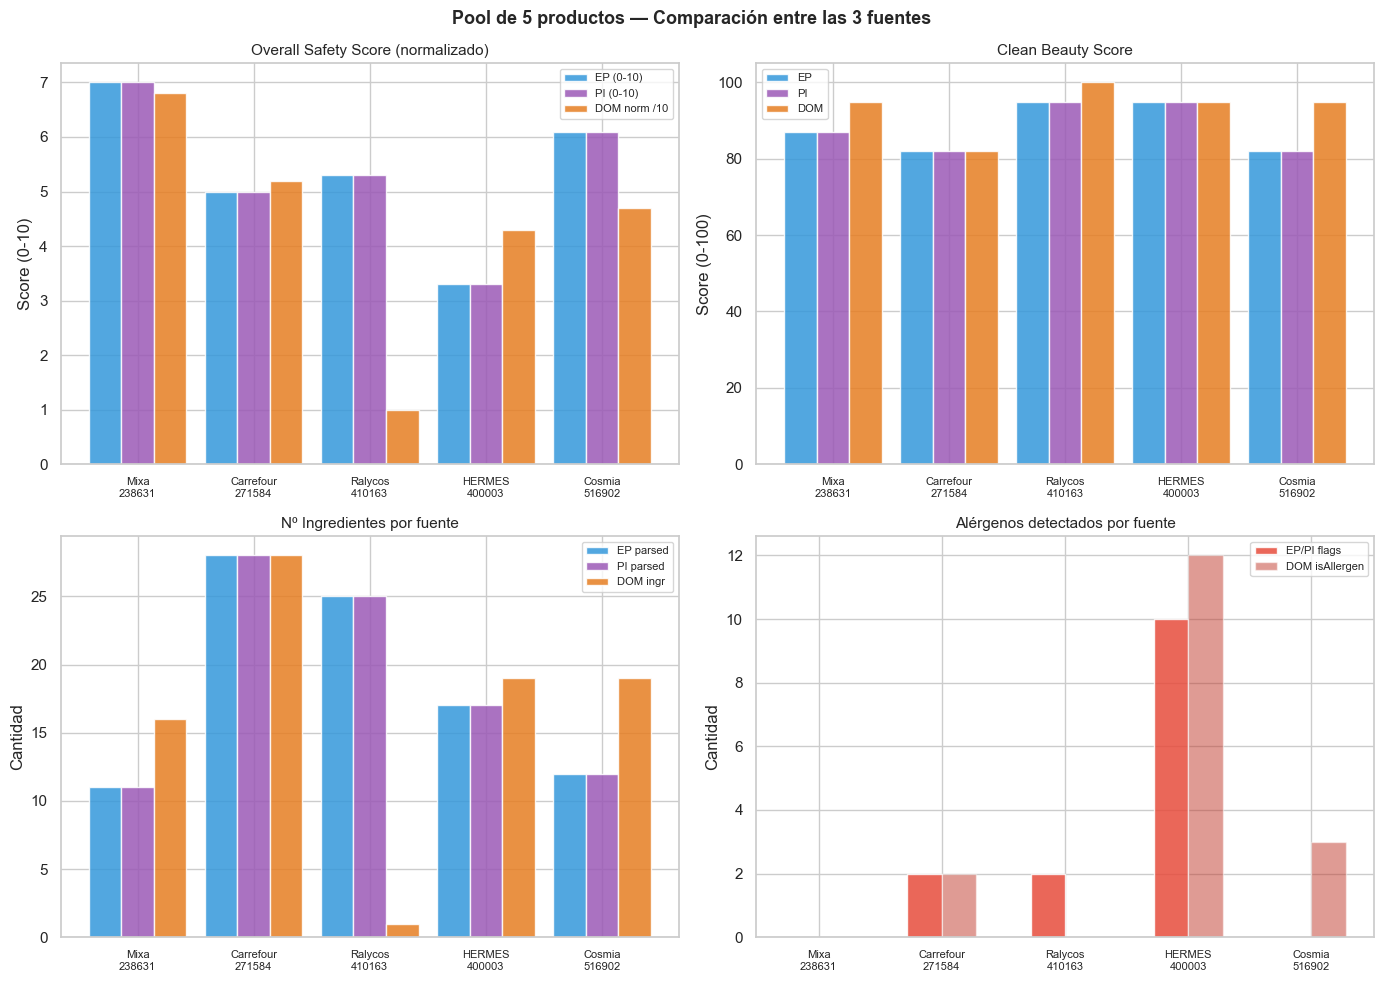

In [56]:
# Visualización comparativa del pool
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x = range(len(df_pool))
labels = [f"{r['marca']}\n{r['barcode'][-6:]}" for _, r in df_pool.iterrows()]
w = 0.28

# Safety score comparado (normalizado)
ax = axes[0, 0]
ax.bar([i - w for i in x], df_pool['safety_EP_010'], width=w, label='EP (0-10)', color='#3498db', alpha=0.85)
ax.bar([i     for i in x], df_pool['safety_PI_010'], width=w, label='PI (0-10)', color='#9b59b6', alpha=0.85)
ax.bar([i + w for i in x], df_pool['safety_DOM_norm_010'], width=w, label='DOM norm /10', color='#e67e22', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_title('Overall Safety Score (normalizado)', fontsize=11)
ax.set_ylabel('Score (0-10)')
ax.legend(fontsize=8)

# Clean beauty score
ax = axes[0, 1]
ax.bar([i - w for i in x], df_pool['clean_beauty_EP'],  width=w, label='EP',  color='#3498db', alpha=0.85)
ax.bar([i     for i in x], df_pool['clean_beauty_PI'],  width=w, label='PI',  color='#9b59b6', alpha=0.85)
ax.bar([i + w for i in x], df_pool['clean_beauty_DOM'], width=w, label='DOM', color='#e67e22', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_title('Clean Beauty Score', fontsize=11)
ax.set_ylabel('Score (0-100)')
ax.legend(fontsize=8)

# Nº ingredientes
ax = axes[1, 0]
ax.bar([i - w for i in x], df_pool['n_parsed_ingr_EP'], width=w, label='EP parsed', color='#3498db', alpha=0.85)
ax.bar([i     for i in x], df_pool['n_parsed_ingr_PI'], width=w, label='PI parsed', color='#9b59b6', alpha=0.85)
ax.bar([i + w for i in x], df_pool['n_ingr_DOM'],       width=w, label='DOM ingr', color='#e67e22', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_title('Nº Ingredientes por fuente', fontsize=11)
ax.set_ylabel('Cantidad')
ax.legend(fontsize=8)

# Alérgenos
ax = axes[1, 1]
ax.bar([i - w/2 for i in x], df_pool['n_allergen_flags_EP'], width=w, label='EP/PI flags', color='#e74c3c', alpha=0.85)
ax.bar([i + w/2 for i in x], df_pool['n_allergen_DOM'],      width=w, label='DOM isAllergen', color='#c0392b', alpha=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_title('Alérgenos detectados por fuente', fontsize=11)
ax.set_ylabel('Cantidad')
ax.legend(fontsize=8)

plt.suptitle(f'Pool de {len(df_pool)} productos — Comparación entre las 3 fuentes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [57]:
# Campos exclusivos de DOM en el pool
print('=== Campos exclusivos de DOM (no disponibles en EP/PI) ===')
dom_exclusive = [
    'efficacySummary', 'environmentalProfile',
    'skinTypeRecommendations', 'skinCompatibility',
    'compatibilityConflicts', 'allergenWarnings', 'pregnancyWarnings'
]
for bc in POOL_BARCODES:
    dom = idx_dom[bc]['dom_data']
    ep  = idx_ep[bc]['data']['product']
    print(f'\nBarcode: {bc} — {ep["name"]}')
    eff = dom.get('efficacySummary', {})
    print(f'  Efficacy evidenceScore:    {eff.get("evidenceScore")}')
    print(f'  Top effects:               {[e["target"] for e in (eff.get("topEffects") or [])[:3]]}')
    env = dom.get('environmentalProfile', {})
    print(f'  Vegan count:               {env.get("veganCount")} / {env.get("totalIngredients")}')
    print(f'  Reef safe count:           {env.get("reefSafeCount")}')
    print(f'  Endocrine disruptors:      {len(env.get("endocrineDisruptors") or [])}')
    print(f'  IARC classified:           {len(env.get("iarcClassified") or [])}')
    skin_compat = dom.get('skinCompatibility', [])
    print(f'  Skin compatibility types:  {[s["skinType"] for s in skin_compat]}')
    preg_warn = dom.get('pregnancyWarnings', [])
    print(f'  Pregnancy warnings:        {preg_warn}')

=== Campos exclusivos de DOM (no disponibles en EP/PI) ===

Barcode: 3600550238631 — Gel Corps Chaveux Bebe Mixa
  Efficacy evidenceScore:    17
  Top effects:               ['anti_acne', 'barrier_repair', 'exfoliating']
  Vegan count:               0 / 16
  Reef safe count:           0
  Endocrine disruptors:      0
  IARC classified:           0
  Skin compatibility types:  ['sensitive', 'oily', 'dry', 'combination', 'acne-prone', 'normal']
  Pregnancy warnings:        ['SALICYLIC ACID: avoid during pregnancy']

Barcode: 8431876271584 — Gel de baño leche
  Efficacy evidenceScore:    13
  Top effects:               ['barrier_repair', 'anti_hyperpigmentation', 'exfoliating']
  Vegan count:               0 / 28
  Reef safe count:           0
  Endocrine disruptors:      0
  IARC classified:           0
  Skin compatibility types:  ['sensitive', 'oily', 'dry', 'combination', 'acne-prone', 'normal']
  Pregnancy warnings:        []

Barcode: 8906163410163 — Ecavitam Lotion
  Efficacy evide

## 6. Construcción de DataFrames Limpios

In [58]:
# --- df_ep: productos con sus metadatos completos ---
def parse_ep_product(r):
    data = r.get('data', {})
    prod = data.get('product')
    if not prod:
        return None
    det  = data.get('details', {}) or {}
    anal = det.get('analysis') or {}
    return {
        'barcode':          r['barcode'],
        'name':             prod.get('name'),
        'brand':            prod.get('brand') or None,
        'manufacturer':     prod.get('manufacturer') or None,
        'country':          prod.get('country') or None,
        'vertical':         prod.get('vertical'),
        'quality_score':    prod.get('qualityScore'),
        'data_sources':     ','.join(prod.get('dataSources', []) or []),
        'has_image':        len(prod.get('imageUrls', []) or []) > 0,
        'packaging':        prod.get('packaging'),
        'n_categories':     len(prod.get('category', []) or []),
        'spf':              det.get('spf'),
        'certifications':   ','.join(det.get('certifications', []) or []),
        'has_analysis':     bool(anal),
        'overall_safety':   anal.get('overallSafetyScore'),  # escala 0-10
        'safety_level':     anal.get('safetyLevel'),
        'clean_beauty':     anal.get('cleanBeautyScore'),
        'comedogenicity':   anal.get('comedogenicityScore'),
        'pregnancy_safe':   anal.get('pregnancySafe'),
        'n_allergen_flags': len(anal.get('allergenFlags', []) or []),
        'n_parsed_ingr':    len(anal.get('parsedIngredients', []) or []),
        'pfas_count':       len(anal.get('pfasIngredients', []) or []),
    }

df_ep = pd.DataFrame([r for r in (parse_ep_product(r) for r in raw_ep) if r])
df_ep_anal = df_ep[df_ep['has_analysis']].copy()
print(f'df_ep: {len(df_ep):,} productos  |  con análisis: {len(df_ep_anal):,}')
df_ep.head(2)

df_ep: 41,248 productos  |  con análisis: 17,577


,barcode,name,brand,manufacturer,country,vertical,quality_score,data_sources,has_image,packaging,n_categories,spf,certifications,has_analysis,overall_safety,safety_level,clean_beauty,comedogenicity,pregnancy_safe,n_allergen_flags,n_parsed_ingr,pfas_count
0,00000014,Süßlupinen Mehl,Bodylab 24,NaN,germany,skincare,64,open_beauty_facts,False,NaN,0,NaN,"organic,eu-organic,eg-öko-verordnung",True,2.0,safe,100.0,0.0,True,1,24,0
1,00000092,airpods,Apple,NaN,france,skincare,55,open_beauty_facts,False,NaN,0,NaN,,False,NaN,NaN,NaN,NaN,None,0,0,0


In [59]:
# --- df_dom: productos + campos exclusivos DOM ---
dom_rows = []
for r in raw_dom:
    dom = r.get('dom_data', {})
    if not dom:
        continue
    env = dom.get('environmentalProfile', {}) or {}
    eff = dom.get('efficacySummary', {}) or {}
    dom_rows.append({
        'barcode':              r['barcode'],
        'safety_0100':          dom.get('overallSafetyScore'),  # escala 0-100
        'safety_norm_010':      round((dom.get('overallSafetyScore') or 0) / 10, 2),
        'clean_beauty':         dom.get('cleanBeautyScore'),
        'pregnancy_safe':       dom.get('pregnancySafe'),
        'n_ingredients':        len(dom.get('ingredients', []) or []),
        'n_allergen_ingr':      sum(1 for i in (dom.get('ingredients') or []) if i.get('isAllergen')),
        'vegan_count':          env.get('veganCount'),
        'non_vegan_count':      env.get('nonVeganCount'),
        'reef_safe_count':      env.get('reefSafeCount'),
        'n_endocrine':          len(env.get('endocrineDisruptors', []) or []),
        'n_iarc':               len(env.get('iarcClassified', []) or []),
        'avg_natural_origin':   env.get('averageNaturalOrigin'),
        'evidence_score':       eff.get('evidenceScore'),
        'n_pregnancy_warnings': len(dom.get('pregnancyWarnings', []) or []),
        'n_allergen_warnings':  len(dom.get('allergenWarnings', []) or []),
    })

df_dom_prod = pd.DataFrame(dom_rows)
print(f'df_dom_prod: {len(df_dom_prod):,} productos')
df_dom_prod.head(2)

df_dom_prod: 41,248 productos


,barcode,safety_0100,safety_norm_010,clean_beauty,pregnancy_safe,n_ingredients,n_allergen_ingr,vegan_count,non_vegan_count,reef_safe_count,n_endocrine,n_iarc,avg_natural_origin,evidence_score,n_pregnancy_warnings,n_allergen_warnings
0,00000014,20,2.0,100,True,24,1,0,0,0,0,0,0,NaN,0,1
1,00000092,20,2.0,100,True,24,1,0,0,0,0,0,0,NaN,0,1


In [60]:
# --- df_ingr: ingredientes del EP (con flag found) ---
ingr_rows = []
for r in raw_ep:
    anal = (r.get('data', {}).get('details') or {}).get('analysis') or {}
    for ing in (anal.get('parsedIngredients') or []):
        ingr_rows.append({
            'barcode':       r['barcode'],
            'inci_name':     ing.get('inciName'),
            'safety_score':  ing.get('safetyScore'),
            'safety_level':  ing.get('safetyLevel'),
            'is_allergen':   ing.get('isAllergen'),
            'allergen_types':','.join(ing.get('allergenTypes', []) or []),
            'comedogenicity':ing.get('comedogenicityRating'),
            'irritancy':     ing.get('irritancyPotential'),
            'pregnancy_safe':ing.get('pregnancySafe'),
            'found':         ing.get('found'),
        })

df_ingr = pd.DataFrame(ingr_rows)
df_ingr_clean = df_ingr[df_ingr['found'] == True].copy()
print(f'df_ingr total: {len(df_ingr):,} | reconocidos (found=True): {len(df_ingr_clean):,} ({100*len(df_ingr_clean)/len(df_ingr):.1f}%)')

# --- df_ingr_dom: ingredientes DOM con sus campos extra ---
dom_ingr_rows = []
for r in raw_dom:
    for ing in (r.get('dom_data', {}).get('ingredients') or []):
        dom_ingr_rows.append({
            'barcode':           r['barcode'],
            'inci_name':         ing.get('inciName'),
            'safety_rating':     ing.get('safetyRating'),  # DOM escala ingrediente
            'functions':         ','.join(ing.get('functions', []) or []),
            'is_allergen':       ing.get('isAllergen'),
            'allergen_type':     ing.get('allergenType'),
            'pregnancy_safe':    ing.get('isPregnancySafe'),
            'comedogenicity':    ing.get('comedogenicity'),
            'breastfeeding_safe':ing.get('breastfeedingSafe'),
            'vegan':             ing.get('vegan'),
            'reef_safe':         ing.get('reefSafe'),
            'fungal_acne_safe':  ing.get('fungalAcneSafe'),
            'photosensitivity':  ing.get('photosensitivityRisk'),
            'natural_origin_pct':ing.get('naturalOriginPercent'),
            'endocrine_risk':    ing.get('endocrineDisruptionRisk'),
            'carcinogenicity':   ing.get('carcinogenicityClass'),
        })

df_ingr_dom = pd.DataFrame(dom_ingr_rows)
print(f'df_ingr_dom: {len(df_ingr_dom):,} ingredientes')

df_ingr total: 293,050 | reconocidos (found=True): 227,774 (77.7%)
df_ingr_dom: 310,765 ingredientes


## 7. Calidad y Nulos por Dataset

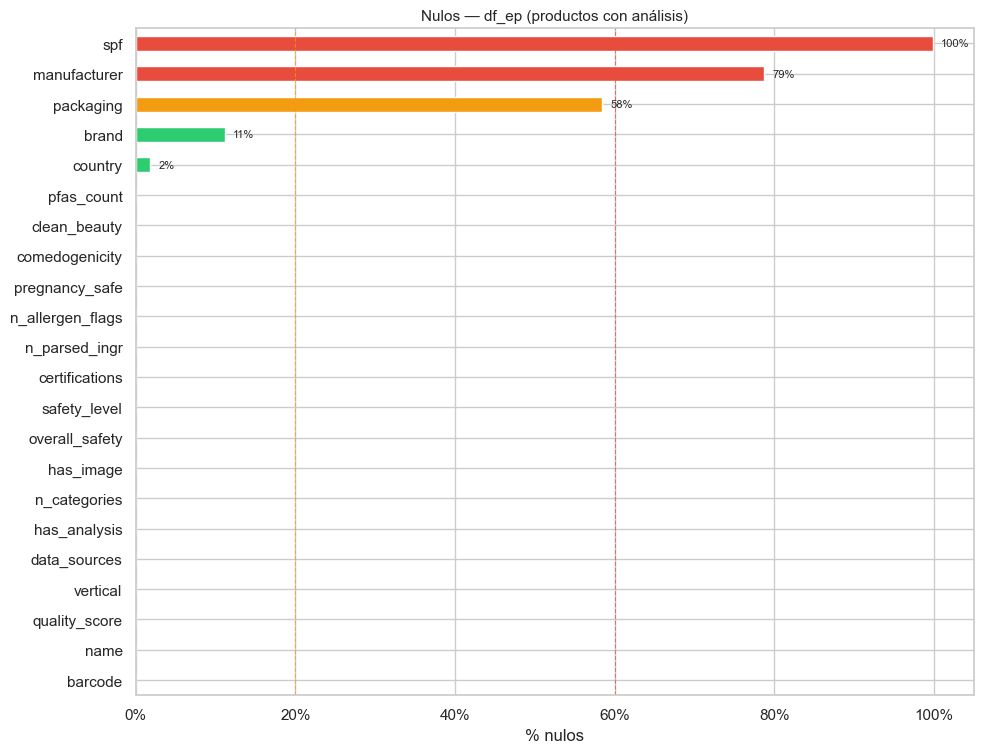

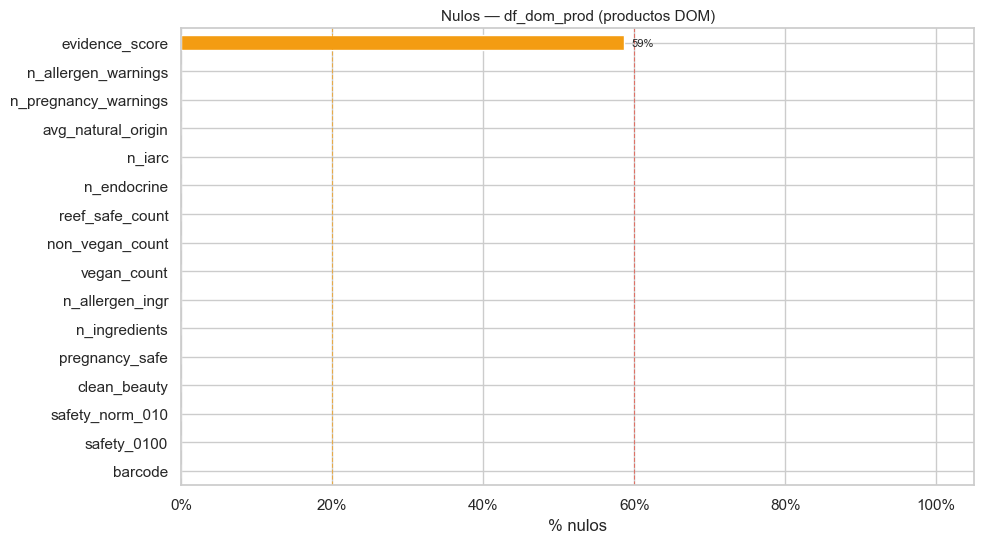

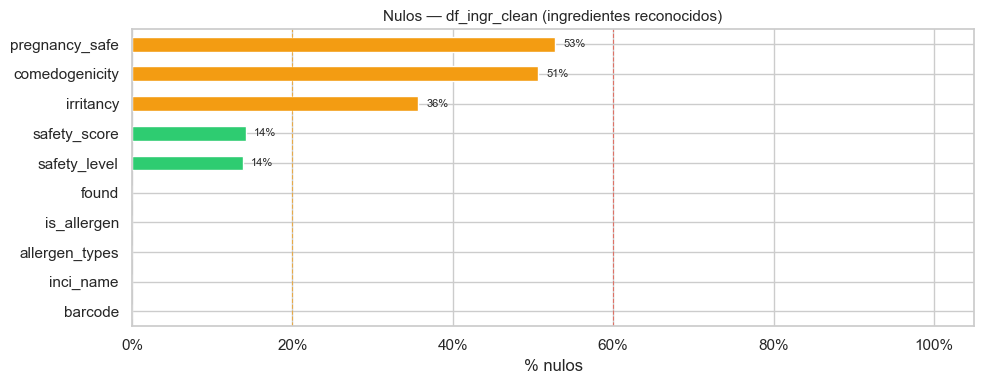

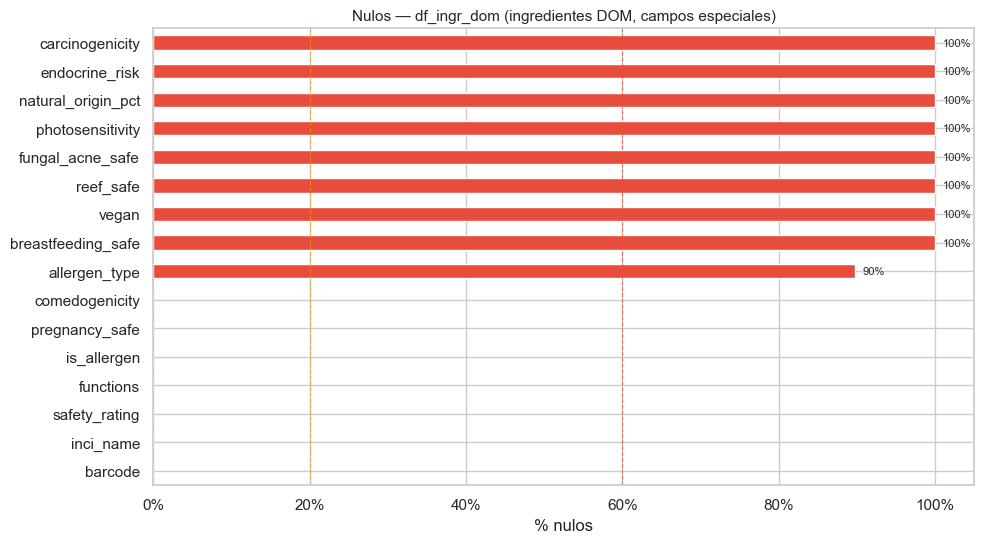

In [61]:
def null_heatmap(df, title, max_cols=25):
    subset = df.iloc[:, :max_cols] if len(df.columns) > max_cols else df
    null_pct = subset.isnull().mean() * 100
    null_pct = null_pct.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(null_pct) * 0.35)))
    colors = ['#2ecc71' if v < 20 else '#f39c12' if v < 60 else '#e74c3c' for v in null_pct]
    null_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(20, color='#f39c12', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axvline(60, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('% nulos')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_xlim(0, 105)
    for p in ax.patches:
        v = p.get_width()
        if v > 0:
            ax.text(v + 1, p.get_y() + p.get_height()/2, f'{v:.0f}%', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

null_heatmap(df_ep_anal, 'Nulos — df_ep (productos con análisis)')
null_heatmap(df_dom_prod, 'Nulos — df_dom_prod (productos DOM)')
null_heatmap(df_ingr_clean, 'Nulos — df_ingr_clean (ingredientes reconocidos)')
null_heatmap(df_ingr_dom, 'Nulos — df_ingr_dom (ingredientes DOM, campos especiales)')

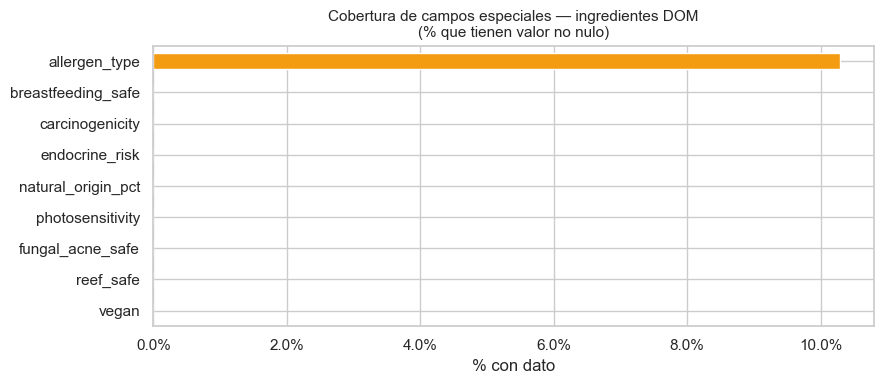

Nota: campos con <10% cobertura tienen utilidad limitada para análisis masivo.


In [62]:
# Cobertura de campos especiales DOM: qué % de ingredientes tienen dato real
special_dom_cols = ['vegan','reef_safe','fungal_acne_safe','photosensitivity',
                    'natural_origin_pct','endocrine_risk','carcinogenicity',
                    'breastfeeding_safe','allergen_type']
coverage = {c: df_ingr_dom[c].notna().mean() * 100
            for c in special_dom_cols if c in df_ingr_dom.columns}

fig, ax = plt.subplots(figsize=(9, 4))
pd.Series(coverage).sort_values().plot(
    kind='barh', ax=ax,
    color=['#e74c3c' if v < 10 else '#f39c12' if v < 50 else '#2ecc71' for v in sorted(coverage.values())]
)
ax.set_title('Cobertura de campos especiales — ingredientes DOM\n(% que tienen valor no nulo)', fontsize=11)
ax.set_xlabel('% con dato')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()
print('Nota: campos con <10% cobertura tienen utilidad limitada para análisis masivo.')

## 8. Análisis de Productos (Entorno de Prueba)

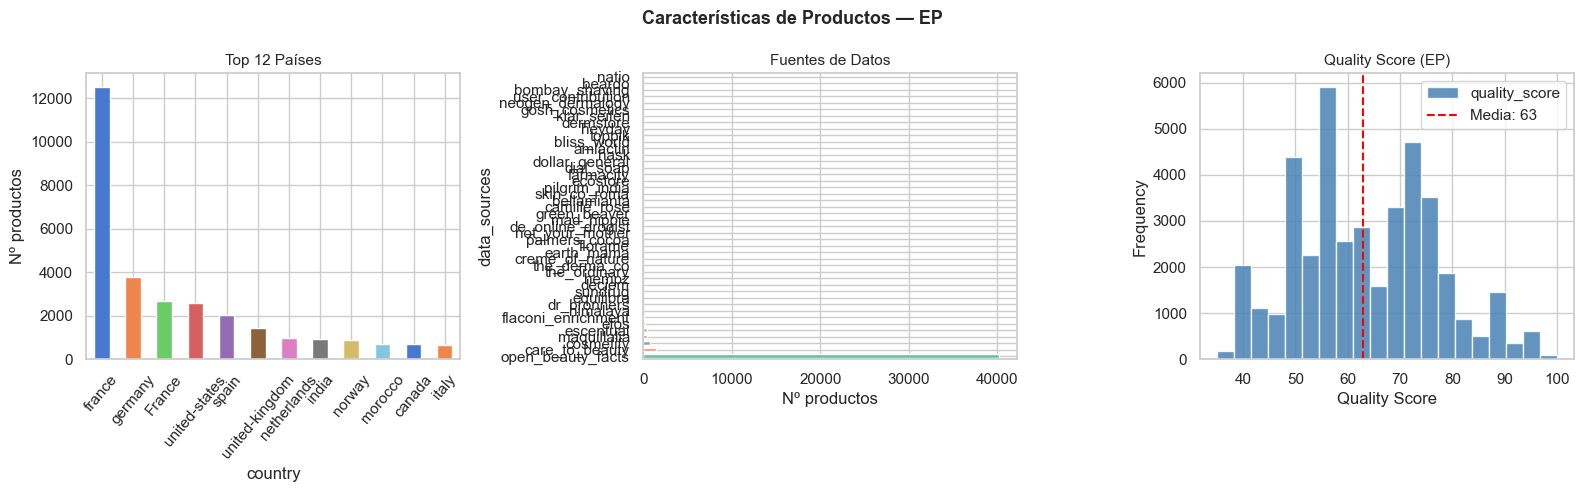

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Top países
df_ep['country'].value_counts().head(12).plot(
    kind='bar', ax=axes[0], color=sns.color_palette('muted', 12), edgecolor='white'
)
axes[0].set_title('Top 12 Países', fontsize=11)
axes[0].tick_params(axis='x', rotation=50)
axes[0].set_ylabel('Nº productos')

# Data sources
ds = (df_ep['data_sources'].str.split(',').explode().str.strip().value_counts())
ds.plot(kind='barh', ax=axes[1], color=sns.color_palette('Set2', len(ds)), edgecolor='white')
axes[1].set_title('Fuentes de Datos', fontsize=11)
axes[1].set_xlabel('Nº productos')

# Quality score
df_ep['quality_score'].dropna().plot(
    kind='hist', bins=20, ax=axes[2], color='steelblue', edgecolor='white', alpha=0.85
)
axes[2].axvline(df_ep['quality_score'].mean(), color='red', linestyle='--',
                label=f'Media: {df_ep["quality_score"].mean():.0f}')
axes[2].set_title('Quality Score (EP)', fontsize=11)
axes[2].set_xlabel('Quality Score')
axes[2].legend()

plt.suptitle('Características de Productos — EP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Análisis de Seguridad — EP/PI vs DOM

Productos con datos EP + DOM: 17,577


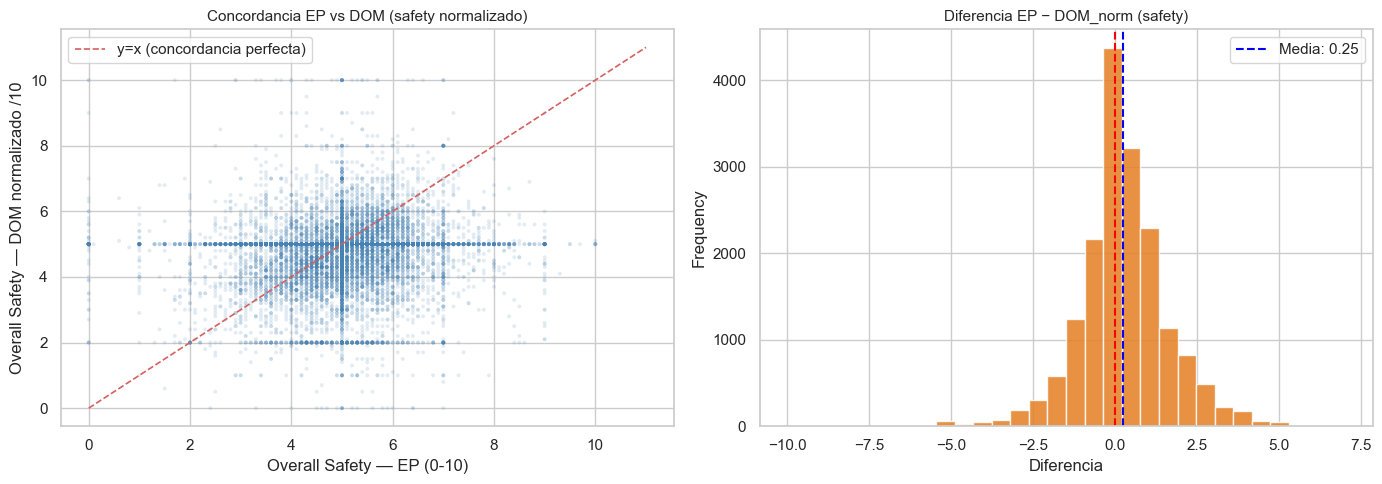

Correlación EP vs DOM_norm: 0.0993
Diferencia media EP - DOM_norm: 0.247  |  std: 1.394


In [64]:
# Merge EP + DOM por barcode para comparar safety normalizado
df_merged = df_ep_anal.merge(
    df_dom_prod[['barcode','safety_norm_010','clean_beauty','n_endocrine','n_iarc',
                 'evidence_score','avg_natural_origin','vegan_count','n_ingredients']],
    on='barcode',
    suffixes=('_ep', '_dom')
)
print(f'Productos con datos EP + DOM: {len(df_merged):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: EP safety vs DOM safety normalizado
axes[0].scatter(
    df_merged['overall_safety'], df_merged['safety_norm_010'],
    alpha=0.15, s=8, color='steelblue', edgecolors='none'
)
lim = [0, 11]
axes[0].plot(lim, lim, 'r--', linewidth=1.2, label='y=x (concordancia perfecta)')
axes[0].set_xlabel('Overall Safety — EP (0-10)')
axes[0].set_ylabel('Overall Safety — DOM normalizado /10')
axes[0].set_title('Concordancia EP vs DOM (safety normalizado)', fontsize=11)
axes[0].legend()

diff = df_merged['overall_safety'] - df_merged['safety_norm_010']
diff.plot(kind='hist', bins=30, ax=axes[1], color='#e67e22', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].axvline(diff.mean(), color='blue', linestyle='--', label=f'Media: {diff.mean():.2f}')
axes[1].set_title('Diferencia EP − DOM_norm (safety)', fontsize=11)
axes[1].set_xlabel('Diferencia')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Correlación EP vs DOM_norm: {df_merged["overall_safety"].corr(df_merged["safety_norm_010"]):.4f}')
print(f'Diferencia media EP - DOM_norm: {diff.mean():.3f}  |  std: {diff.std():.3f}')

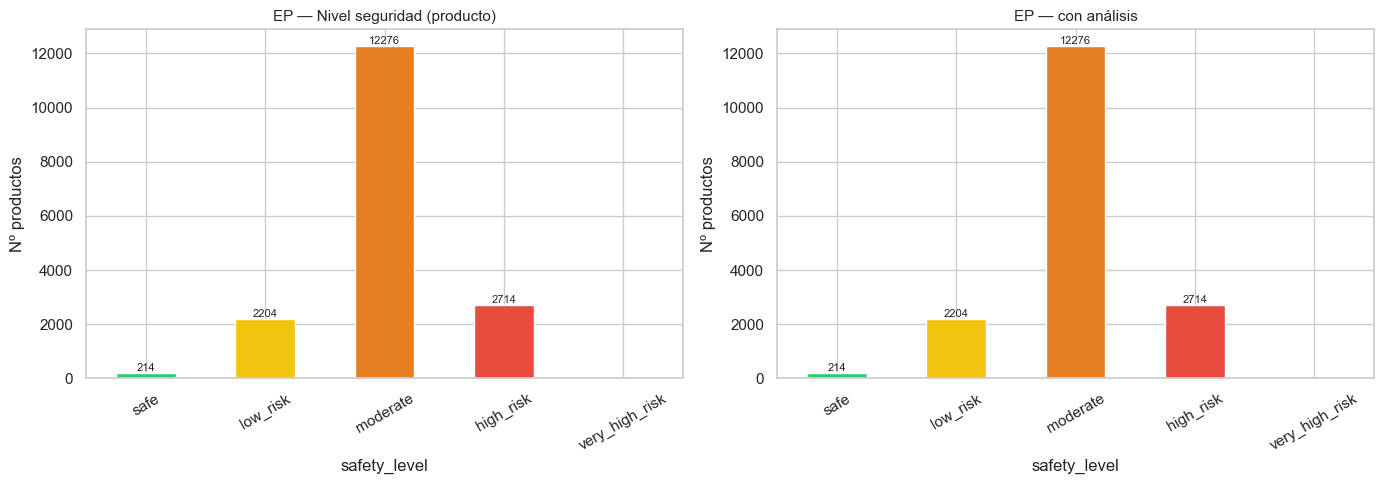

In [65]:
# Distribución de niveles de seguridad
safety_order = ['safe', 'low_risk', 'moderate', 'high_risk', 'very_high_risk']
colors_s = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in [
    (axes[0], 'safety_level', 'EP — Nivel seguridad (producto)'),
    (axes[1], 'safety_level', 'EP — con análisis')
]:
    counts = df_ep_anal[col].value_counts().reindex(safety_order, fill_value=0)
    counts.plot(kind='bar', ax=ax, color=colors_s[:len(counts)], edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('Nº productos')
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}',
                        (p.get_x()+p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 10. Análisis de Ingredientes

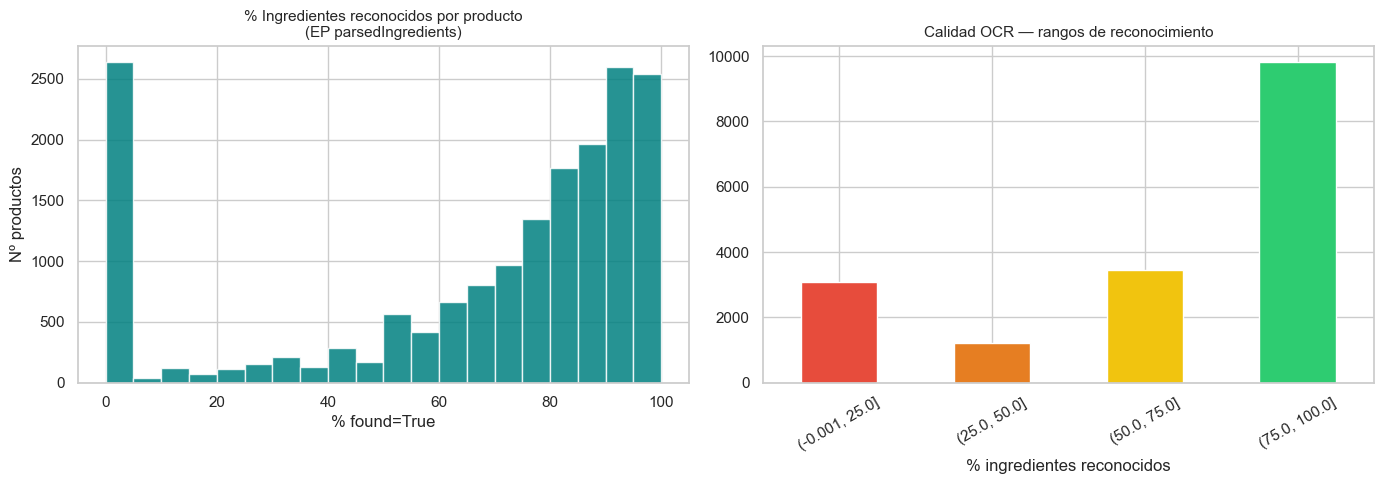

Estadísticas % found:
count    17574.0
mean        66.6
std         33.3
min          0.0
25%         53.5
50%         80.0
75%         91.4
max        100.0


In [66]:
# Tasa de reconocimiento por producto
found_rate = df_ingr.groupby('barcode')['found'].agg(
    total='count', found_n=lambda x: (x == True).sum()
)
found_rate['pct_found'] = found_rate['found_n'] / found_rate['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

found_rate['pct_found'].plot(
    kind='hist', bins=20, ax=axes[0], color='teal', edgecolor='white', alpha=0.85
)
axes[0].set_title('% Ingredientes reconocidos por producto\n(EP parsedIngredients)', fontsize=11)
axes[0].set_xlabel('% found=True')
axes[0].set_ylabel('Nº productos')

pd.cut(found_rate['pct_found'], bins=[0,25,50,75,100], include_lowest=True).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'], edgecolor='white'
)
axes[1].set_title('Calidad OCR — rangos de reconocimiento', fontsize=11)
axes[1].set_xlabel('% ingredientes reconocidos')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
print('Estadísticas % found:')
print(found_rate['pct_found'].describe().round(1).to_string())

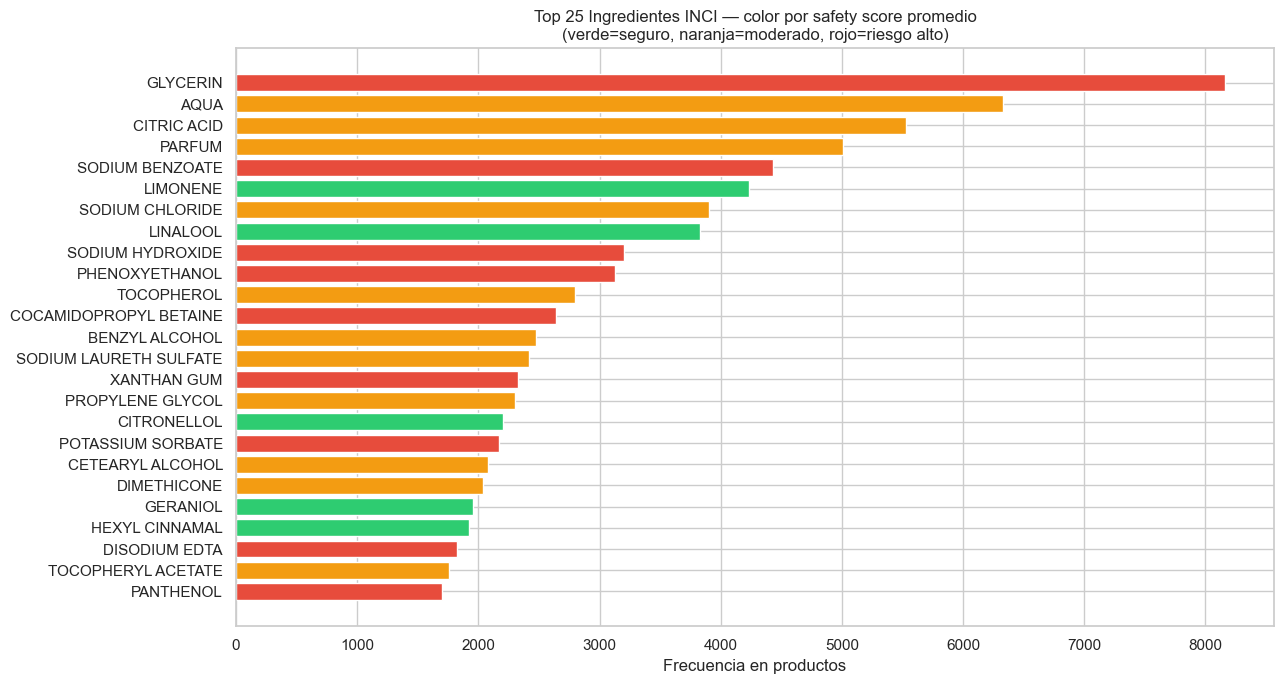

In [67]:
# Top ingredientes + seguridad
top_ingr = df_ingr_clean['inci_name'].value_counts().head(25)

# Color por safety score promedio
ingr_avg_safety = df_ingr_clean.groupby('inci_name')['safety_score'].mean()
top_colors = [
    '#e74c3c' if ingr_avg_safety.get(n, 5) >= 7
    else '#f39c12' if ingr_avg_safety.get(n, 5) >= 4
    else '#2ecc71'
    for n in top_ingr.index
]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top_ingr.index[::-1], top_ingr.values[::-1], color=top_colors[::-1], edgecolor='white')
ax.set_title('Top 25 Ingredientes INCI — color por safety score promedio\n(verde=seguro, naranja=moderado, rojo=riesgo alto)', fontsize=12)
ax.set_xlabel('Frecuencia en productos')
plt.tight_layout()
plt.show()

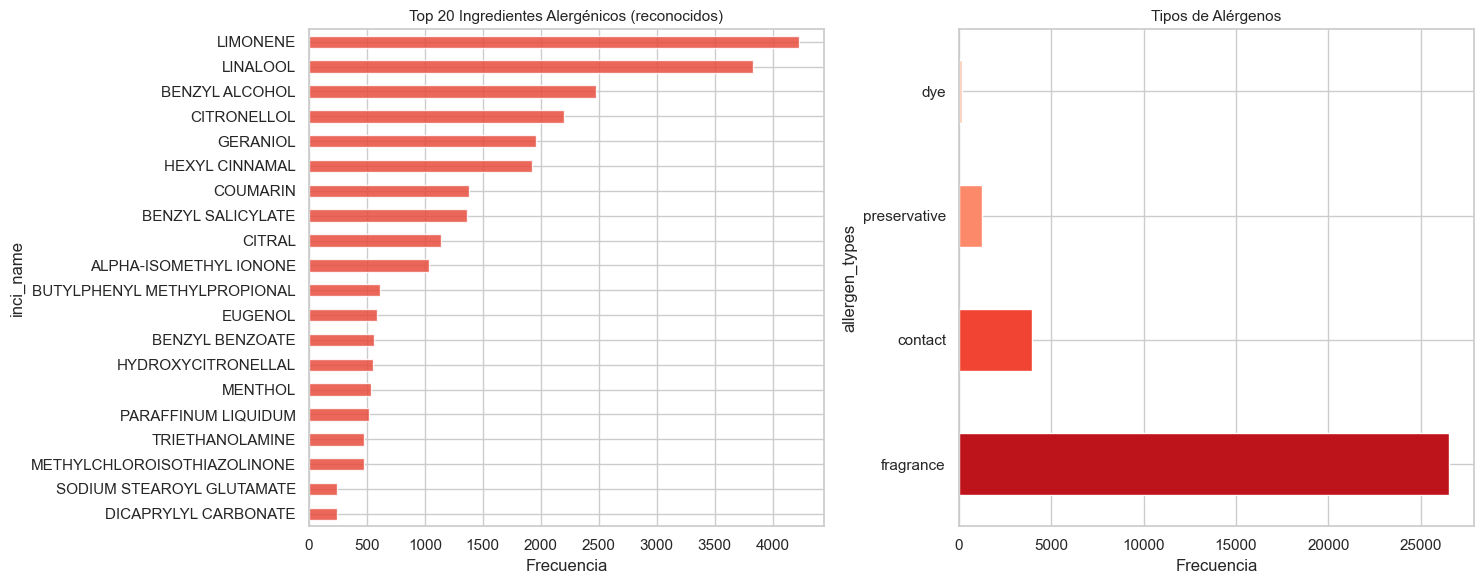

In [68]:
# Alérgenos y tipos
allergens = df_ingr_clean[df_ingr_clean['is_allergen'] == True]
top_allergens = allergens['inci_name'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_allergens.plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title('Top 20 Ingredientes Alergénicos (reconocidos)', fontsize=11)
axes[0].set_xlabel('Frecuencia')

allergen_types = (
    df_ingr_clean[df_ingr_clean['allergen_types'] != '']
    ['allergen_types'].str.split(',').explode().str.strip().value_counts()
)
if len(allergen_types) > 0:
    allergen_types.plot(kind='barh', ax=axes[1],
                        color=sns.color_palette('Reds_r', len(allergen_types)))
    axes[1].set_title('Tipos de Alérgenos', fontsize=11)
    axes[1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()

## 11. Campos Exclusivos DOM — Eficacia y Perfil Ambiental

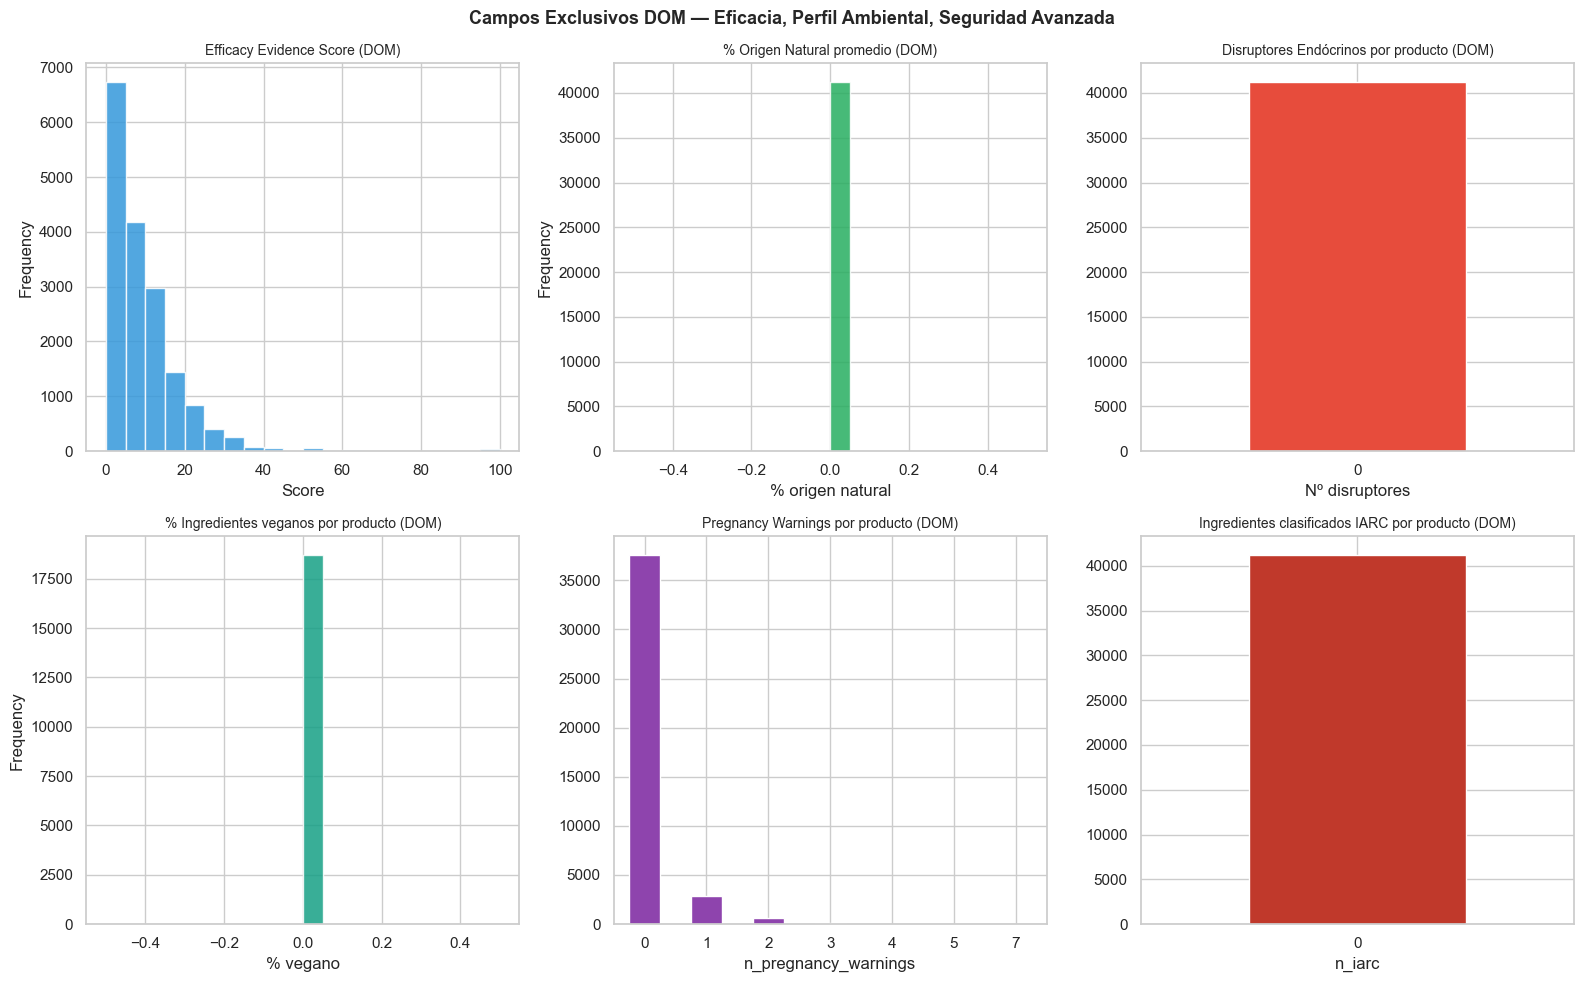

In [69]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Evidence score
df_dom_prod['evidence_score'].dropna().plot(
    kind='hist', bins=20, ax=axes[0,0], color='#3498db', edgecolor='white', alpha=0.85
)
axes[0,0].set_title('Efficacy Evidence Score (DOM)', fontsize=10)
axes[0,0].set_xlabel('Score')

# Avg natural origin %
df_dom_prod['avg_natural_origin'].dropna().plot(
    kind='hist', bins=20, ax=axes[0,1], color='#27ae60', edgecolor='white', alpha=0.85
)
axes[0,1].set_title('% Origen Natural promedio (DOM)', fontsize=10)
axes[0,1].set_xlabel('% origen natural')

# Endocrine disruptors por producto
df_dom_prod['n_endocrine'].value_counts().sort_index().head(10).plot(
    kind='bar', ax=axes[0,2], color='#e74c3c', edgecolor='white'
)
axes[0,2].set_title('Disruptores Endócrinos por producto (DOM)', fontsize=10)
axes[0,2].set_xlabel('Nº disruptores')
axes[0,2].tick_params(axis='x', rotation=0)

# Vegan ratio
df_dom_prod_v = df_dom_prod.dropna(subset=['vegan_count','n_ingredients'])
df_dom_prod_v = df_dom_prod_v[df_dom_prod_v['n_ingredients'] > 0].copy()
df_dom_prod_v['vegan_ratio'] = df_dom_prod_v['vegan_count'] / df_dom_prod_v['n_ingredients'] * 100
df_dom_prod_v['vegan_ratio'].plot(
    kind='hist', bins=20, ax=axes[1,0], color='#16a085', edgecolor='white', alpha=0.85
)
axes[1,0].set_title('% Ingredientes veganos por producto (DOM)', fontsize=10)
axes[1,0].set_xlabel('% vegano')

# Pregnancy warnings
df_dom_prod['n_pregnancy_warnings'].value_counts().sort_index().head(8).plot(
    kind='bar', ax=axes[1,1], color='#8e44ad', edgecolor='white'
)
axes[1,1].set_title('Pregnancy Warnings por producto (DOM)', fontsize=10)
axes[1,1].tick_params(axis='x', rotation=0)

# IARC classified
df_dom_prod['n_iarc'].value_counts().sort_index().head(8).plot(
    kind='bar', ax=axes[1,2], color='#c0392b', edgecolor='white'
)
axes[1,2].set_title('Ingredientes clasificados IARC por producto (DOM)', fontsize=10)
axes[1,2].tick_params(axis='x', rotation=0)

plt.suptitle('Campos Exclusivos DOM — Eficacia, Perfil Ambiental, Seguridad Avanzada',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

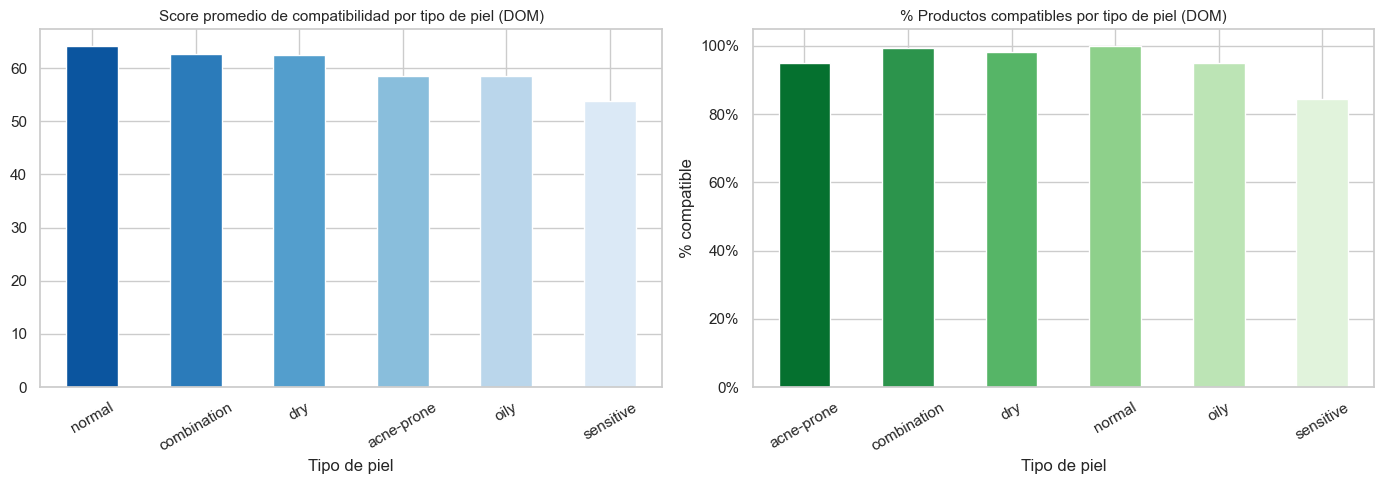

In [70]:
# Skin compatibility (DOM) — distribución por tipo de piel
skin_compat_rows = []
for r in raw_dom:
    for sc in (r.get('dom_data', {}).get('skinCompatibility') or []):
        skin_compat_rows.append({
            'barcode':    r['barcode'],
            'skin_type':  sc.get('skinType'),
            'compatible': sc.get('compatible'),
            'score':      sc.get('score'),
        })

df_skin = pd.DataFrame(skin_compat_rows)

if len(df_skin) > 0:
    skin_avg = df_skin.groupby('skin_type')['score'].mean().sort_values(ascending=False)
    skin_compat_rate = df_skin.groupby('skin_type')['compatible'].mean() * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    skin_avg.plot(kind='bar', ax=axes[0], color=sns.color_palette('Blues_r', len(skin_avg)), edgecolor='white')
    axes[0].set_title('Score promedio de compatibilidad por tipo de piel (DOM)', fontsize=11)
    axes[0].set_xlabel('Tipo de piel')
    axes[0].tick_params(axis='x', rotation=30)

    skin_compat_rate.plot(kind='bar', ax=axes[1], color=sns.color_palette('Greens_r', len(skin_compat_rate)), edgecolor='white')
    axes[1].set_title('% Productos compatibles por tipo de piel (DOM)', fontsize=11)
    axes[1].set_xlabel('Tipo de piel')
    axes[1].set_ylabel('% compatible')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

    plt.tight_layout()
    plt.show()

## 12. Resumen Ejecutivo

In [71]:
print('=' * 65)
print('RESUMEN EJECUTIVO — DATASET INCI API')
print('=' * 65)

print(f'\n📦 COBERTURA')
print(f'  Barcodes escaneados (EP/PI):     {len(raw_ep):>8,}')
print(f'  Productos encontrados:           {len(ep_valid):>8,}  ({100*len(ep_valid)/len(raw_ep):.1f}%)')
print(f'  Con análisis completo (=DOM):    {len(ep_with_anal):>8,}  ({100*len(ep_with_anal)/len(raw_ep):.1f}%)')
print(f'  DOM ⊆ EP válidos (confirmado):   {dom_barcodes == ep_valid}')

print(f'\n🏗️  ESTRUCTURA JSON')
print(f'  Campos EP / PI / DOM totales:    {sum(1 for _ in schema_ep)} / {sum(1 for _ in schema_pi)} / {sum(1 for _ in schema_dom)}')
print(f'  Campos exclusivos EP:            {len(only_ep)}')
print(f'  Campos exclusivos DOM:           {len(only_dom)}')
print(f'  Análisis EP = Análisis PI:       True (mismas claves, mismos valores)')
print(f'  ALERTA escala safety:            DOM 0-100, EP/PI 0-10 (factor /10)')

print(f'\n🧪 INGREDIENTES')
print(f'  Total parsed (EP):               {len(df_ingr):>8,}')
print(f'  Reconocidos (found=True):        {len(df_ingr_clean):>8,}  ({100*len(df_ingr_clean)/len(df_ingr):.1f}%)')
print(f'  Únicos reconocidos:              {df_ingr_clean["inci_name"].nunique():>8,}')
print(f'  Ingredientes DOM scrapeados:     {len(df_ingr_dom):>8,}')

if len(df_ep_anal) > 0:
    print(f'\n⚠️  SEGURIDAD (EP, escala 0-10)')
    print(f'  Safety score promedio:           {df_ep_anal["overall_safety"].mean():>8.2f}')
    print(f'  Productos safe (score ≤ 3):      {(df_ep_anal["overall_safety"]<=3).sum():>8,}  ({100*(df_ep_anal["overall_safety"]<=3).mean():.1f}%)')
    print(f'  Clean beauty promedio:           {df_ep_anal["clean_beauty"].mean():>8.1f} / 100')
    print(f'  Pregnancy safe:                  {df_ep_anal["pregnancy_safe"].sum():>8,.0f}')
    print(f'  Con ≥1 alérgeno:                 {(df_ep_anal["n_allergen_flags"]>0).sum():>8,}  ({100*(df_ep_anal["n_allergen_flags"]>0).mean():.1f}%)')

if len(df_merged) > 0:
    corr = df_merged['overall_safety'].corr(df_merged['safety_norm_010'])
    print(f'\n🔗 CONCORDANCIA EP vs DOM')
    print(f'  Correlación safety EP vs DOM/10: {corr:.4f}')

print('\n' + '=' * 65)

RESUMEN EJECUTIVO — DATASET INCI API

📦 COBERTURA
  Barcodes escaneados (EP/PI):       64,237
  Productos encontrados:             41,248  (64.2%)
  Con análisis completo (=DOM):      17,577  (27.4%)
  DOM ⊆ EP válidos (confirmado):   True

🏗️  ESTRUCTURA JSON
  Campos EP / PI / DOM totales:    53 / 37 / 55
  Campos exclusivos EP:            16
  Campos exclusivos DOM:           54
  Análisis EP = Análisis PI:       True (mismas claves, mismos valores)
  ALERTA escala safety:            DOM 0-100, EP/PI 0-10 (factor /10)

🧪 INGREDIENTES
  Total parsed (EP):                293,050
  Reconocidos (found=True):         227,774  (77.7%)
  Únicos reconocidos:                 4,440
  Ingredientes DOM scrapeados:      310,765

⚠️  SEGURIDAD (EP, escala 0-10)
  Safety score promedio:               5.04
  Productos safe (score ≤ 3):           796  (4.5%)
  Clean beauty promedio:               94.8 / 100
  Pregnancy safe:                    14,791
  Con ≥1 alérgeno:                    9,332  (53.